# Classic models (MIDI) — vodič kroz notebook

Isti zadatak kao u `classic_models_raw.ipynb` — prepoznavanje kompozitora po djelu — ali atributi se ovdje
izvlače iz MusicNet-ovih note-level (MIDI) anotacija (`train_labels/`, `test_labels/`), ne iz audio signala.
Nikakav `.wav` se ne učita, pa je ovaj pipeline mnogo brži od audio verzije.

Isti metodološki okvir: `work_id` grupisanje, `StratifiedGroupKFold`, work-level majority vote, macro F1
kao glavna metrika (dataset je neuravnotežen po kompozitorima).

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

# Ucitavanje podataka

## Priprema metapodataka

Pregled izvorne tabele i raspodjele kompozitora nalazi se u [metadata.ipynb](metadata.ipynb).
`load_metadata()` iz `dataset.py` učitava CSV, formira `work_id` kao `composer + " | " + composition`
i zadržava kompozitore sa najmanje `MIN_WORKS_PER_COMPOSER` različitih djela (podrazumijevano 5, iz `config.py`).
Svi stavovi istog djela tako ostaju u istoj grupi tokom evaluacije.

Ova sveska se izvršava samostalno; nije potrebno prethodno pokretati `metadata.ipynb`.

In [ ]:
import numpy as np
import pandas as pd

from src.features.dataset import load_metadata
from src.utils.paths import AUDIO_DIR

metadata_filtered = load_metadata()

In [8]:
print(
    metadata_filtered.groupby("composer")["work_id"]
    .nunique()
    .sort_values()
)

composer
Brahms        8
Schubert      9
Mozart       11
Bach         30
Beethoven    55
Name: work_id, dtype: int64


---

## Group-aware evaluacija

Želimo da mjerimo generalizaciju na **nova djela**, ne na nove segmente poznatog djela. `StratifiedGroupKFold`
drži sve segmente istog `work_id` u istom foldu i približno čuva raspodjelu kompozitora po foldovima.

In [ ]:
from sklearn import metrics
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from src.model.evaluation import make_sample_weights, majority_vote_prediction

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

---

# MIDI model

Svaka nota u MusicNet anotacijama ima visinu, instrument, tačan onset/offset i trajanje u otkucajima.
`extract_midi_features` (u `midi.py`) iz toga računa gustinu nota, melodijski kontur (interval mean/std,
udio uzlaznih/silaznih/ponovljenih koraka), histogram tonskih klasa, histogram instrumenata (11 fiksnih GM
programa u MusicNet-u), on-beat/off-beat omjer i raspon akorada.

Napomena: `end_beat` kolona u MusicNet CSV-u je zapravo **trajanje note u otkucajima**, ne apsolutna
pozicija (provjereno — `end_beat < start_beat` za svaki red u fajlu).

In [ ]:
from src.features.midi import make_midi_dataset

X_midi, y_midi, groups_midi = make_midi_dataset(metadata_filtered, AUDIO_DIR)

print(X_midi.shape)

In [14]:
X_midi

,note_density,pitch_mean,pitch_std,pitch_range,interval_mean,interval_std,interval_abs_mean,prop_ascending,prop_descending,prop_repeated,...,instrument_43,instrument_44,instrument_61,instrument_69,instrument_71,instrument_72,instrument_74,velocity_mean,velocity_std,velocity_range
0,8.4,67.833336,11.301952,53.0,0.325301,15.113314,12.951807,0.518072,0.481928,0.000000,...,0.095238,0.047619,0.0,0.0,0.0,0.0,0.0,64.935066,2.408522,11.0
1,6.9,68.782608,10.732410,48.0,0.235294,13.148605,10.147058,0.470588,0.514706,0.014706,...,0.130435,0.028986,0.0,0.0,0.0,0.0,0.0,65.771088,3.430288,11.0
2,6.9,68.043480,14.080961,53.0,-0.205882,17.928419,14.676471,0.470588,0.485294,0.044118,...,0.115942,0.072464,0.0,0.0,0.0,0.0,0.0,63.932434,4.697127,22.0
3,11.6,73.310349,12.267432,65.0,0.017391,15.702662,12.730434,0.530435,0.460870,0.008696,...,0.086207,0.051724,0.0,0.0,0.0,0.0,0.0,64.729279,2.473880,12.0
4,13.1,73.427483,11.237906,59.0,0.046154,14.780373,11.892307,0.515385,0.476923,0.007692,...,0.038168,0.038168,0.0,0.0,0.0,0.0,0.0,64.526314,2.232969,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11066,6.0,50.883335,7.490197,29.0,0.000000,9.890930,8.813560,0.525424,0.474576,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
11067,6.0,49.883335,7.754766,29.0,0.203390,11.382085,9.898305,0.593220,0.406780,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
11068,4.2,60.666668,13.265901,46.0,0.024390,15.770438,11.585366,0.585366,0.414634,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
11069,3.7,66.297295,12.582409,45.0,-0.027778,12.475501,7.583333,0.416667,0.583333,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0


In [56]:
from itertools import product
import time

all_work_true_midi = []
all_work_pred_midi = []

results = []

param_grid = {
    "n_estimators": [500], # tried [50, 100, 300] but models statistically improve with more estimators with ceiling at ~500
    "max_depth": [10, 20], # tried 30 as well - but 20 is ceiling here
    "min_samples_leaf": [1, 3, 5] # regularization
}

grid_start_time = time.time()

for n_est, max_dp, min_slf in product(*param_grid.values()):

    work_acc_scores = []
    work_f1_scores = []
    work_auc_scores = []


    for train_idx, val_idx in sgkf.split(X_midi, y_midi, groups_midi):
        X_train_fold = X_midi[train_idx]
        y_train_fold = y_midi[train_idx]
        groups_train = groups_midi[train_idx]

        X_val_fold = X_midi[val_idx]
        y_val_fold = y_midi[val_idx]
        groups_val = groups_midi[val_idx]

        sample_weights = make_sample_weights(y_train_fold, groups_train)

        model = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=max_dp,
            min_samples_leaf=min_slf,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train_fold, y_train_fold, sample_weight=sample_weights)

        pred = model.predict(X_val_fold)

        work_true, work_pred = majority_vote_prediction(y_val_fold, pred, groups_val)

        work_accuracy = metrics.accuracy_score(
            work_true,
            work_pred
        )

        work_f1 = metrics.f1_score(
            work_true,
            work_pred,
            average = "macro"
        )

        # work_auc = metrics.roc_auc_score(
        #     work_true,
        #     work_pred,
        #     average = "macro",
        #     multi_class = "ovo"
        # )
        work_auc = 0.0

        work_acc_scores.append(work_accuracy)
        work_f1_scores.append(work_f1)
        work_auc_scores.append(work_auc)


        all_work_true_midi.extend(work_true)
        all_work_pred_midi.extend(work_pred)


    mean_acc = np.mean(work_acc_scores)
    mean_f1 = np.mean(work_f1_scores)
    mean_auc = np.mean(work_auc_scores)

    results.append(
        (n_est, max_dp, min_slf, mean_acc, mean_f1, mean_auc)
    )

    print(
        f"n_est={n_est}, max_depth={max_dp}, min_sample_leaf={min_slf}: "
        f"accuracy={mean_acc:.4f}, "
        f"macro_f1={mean_f1:.4f}"
        # f"macro_auc={mean_auc:.4f}"
    )

grid_elapsed = time.time() - grid_start_time
print(
    f"\nRandom Forest grid search "
    f"trajao: {grid_elapsed:.1f}s"
)


n_est=500, max_depth=20, min_sample_leaf=1: accuracy=0.7870, macro_f1=0.6125
n_est=500, max_depth=20, min_sample_leaf=3: accuracy=0.8047, macro_f1=0.6778
n_est=500, max_depth=20, min_sample_leaf=5: accuracy=0.7696, macro_f1=0.6530
n_est=500, max_depth=30, min_sample_leaf=1: accuracy=0.7870, macro_f1=0.6125
n_est=500, max_depth=30, min_sample_leaf=3: accuracy=0.8047, macro_f1=0.6778
n_est=500, max_depth=30, min_sample_leaf=5: accuracy=0.7783, macro_f1=0.6578

Random Forest grid search trajao: 262.8s


In [57]:
def get_max(results):
    max_acc = max([x[3] for x in results])
    max_f1 = max([x[4] for x in results])

    ths = [0.01, 0.05, 0.1, 0.2]
    for th in ths:
        new_results = [res for res in results if (res[3] > (1-th) * max_acc) and (res[4] > (1-th) * max_f1)]

        if results != []:
            results = new_results
            break

    return max(results, key=lambda x : x[4])
    


best = get_max(results)

print("\nBest n_estimators:", best[0])
print("Best max_depth:", best[1])
print("Best min_sample_leaf:", best[2])
print("Best accuracy:", best[3])
print("Best macro F1:", best[4])


Best n_estimators: 500
Best max_depth: 20
Best min_sample_leaf: 3
Best accuracy: 0.8047430830039526
Best macro F1: 0.6778411443628833


In [58]:
n_est, max_dp, min_slf = best[0], best[1], best[2]

all_work_true = []
all_work_pred = []

work_acc_scores = []
work_f1_scores = []

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(X_midi, y_midi, groups_midi),
    start = 1
):
    X_train_fold = X_midi[train_idx]
    y_train_fold = y_midi[train_idx]
    groups_train = groups_midi[train_idx]

    X_val_fold = X_midi[val_idx]
    y_val_fold = y_midi[val_idx]
    groups_val = groups_midi[val_idx]

    sample_weights = make_sample_weights(
        y_train_fold,
        groups_train
    )

    model = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=max_dp,
        min_samples_leaf=min_slf,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_fold,
        y_train_fold,
        sample_weight=sample_weights
    )

    pred = model.predict(X_val_fold)

    work_true, work_pred = majority_vote_prediction(
        y_val_fold,
        pred,
        groups_val
    )

    all_work_true.extend(work_true)
    all_work_pred.extend(work_pred)

    work_accuracy = metrics.accuracy_score(
        work_true,
        work_pred
    )

    work_f1 = metrics.f1_score(
        work_true,
        work_pred,
        average = "macro"
    )

    work_acc_scores.append(work_accuracy)
    work_f1_scores.append(work_f1)

mean_acc = np.mean(work_acc_scores)
mean_f1 = np.mean(work_f1_scores)

grid_elapsed = time.time() - grid_start_time

In [59]:
print(
    metrics.classification_report(
        all_work_true,
        all_work_pred
    )
)

print(
    "Overall work accuracy:",
    metrics.accuracy_score(
        all_work_true,
        all_work_pred
    )
)

print(
    "Overall work macro F1:",
    metrics.f1_score(
        all_work_true,
        all_work_pred,
        average = "macro"
    )
)

              precision    recall  f1-score   support

        Bach       1.00      0.90      0.95        30
   Beethoven       0.85      0.85      0.85        55
      Brahms       0.27      0.38      0.32         8
      Mozart       0.67      0.73      0.70        11
    Schubert       0.75      0.67      0.71         9

    accuracy                           0.81       113
   macro avg       0.71      0.70      0.70       113
weighted avg       0.83      0.81      0.81       113

Overall work accuracy: 0.8053097345132744
Overall work macro F1: 0.7038475752273033


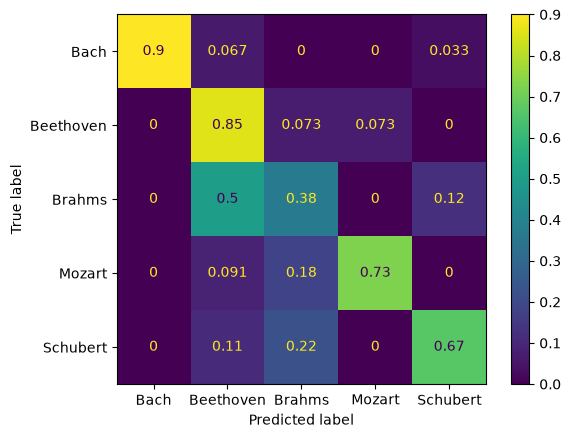

In [60]:
from matplotlib import pyplot as plt

metrics.ConfusionMatrixDisplay.from_predictions(
    all_work_true,
    all_work_pred,
    normalize="true"
)

plt.show()

## ------ SVM Model -------------------------------------- 

In [28]:
import time
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC

C_values = [10 ** i for i in range(-1, 3)]
gamma_values = [0.001, 0.005, 0.01, 0.1]

results = []

grid_start_time = time.time()

for C in C_values:
    for gamma in gamma_values:

        work_acc_scores = []
        work_f1_scores = []

        for fold, (train_idx, val_idx) in enumerate(
            sgkf.split(X_midi, y_midi, groups_midi),
            start = 1
        ):
            X_train_fold = X_midi[train_idx]
            y_train_fold = y_midi[train_idx]
            groups_train = groups_midi[train_idx]

            X_val_fold = X_midi[val_idx]
            y_val_fold = y_midi[val_idx]
            groups_val = groups_midi[val_idx]

            sample_weights = make_sample_weights(
                y_train_fold,
                groups_train
            )

            model = make_pipeline(
                preprocessing.StandardScaler(),

                SVC(
                    kernel = 'rbf',
                    C = C,
                    gamma = gamma,
                    class_weight = None
                )
            )

            model.fit(
                X_train_fold,
                y_train_fold,
                svc__sample_weight = sample_weights
            )

            pred = model.predict(X_val_fold)

            work_true, work_pred = majority_vote_prediction(
                y_val_fold,
                pred,
                groups_val
            )

            work_accuracy = metrics.accuracy_score(
                work_true,
                work_pred
            )

            work_f1 = metrics.f1_score(
                work_true,
                work_pred,
                average = "macro"
            )

            work_acc_scores.append(work_accuracy)
            work_f1_scores.append(work_f1)

        mean_acc = np.mean(work_acc_scores)
        mean_f1 = np.mean(work_f1_scores)

        results.append(
            (C,gamma,mean_acc,mean_f1)
        )

        print(
            f"C={C}, gamma={gamma}: "
            f"accuracy={mean_acc:.4f}, "
            f"macro_f1={mean_f1:.4f}"
        )

grid_elapsed = time.time() - grid_start_time
print(
    f"\nSVM grid search ({len(C_values)} C values x {len(gamma_values)} gamma values x 5 folds) "
    f"trajao: {grid_elapsed:.1f}s"
)

C=0.1, gamma=0.001: accuracy=0.6534, macro_f1=0.5760
C=0.1, gamma=0.005: accuracy=0.7249, macro_f1=0.6540
C=0.1, gamma=0.01: accuracy=0.7427, macro_f1=0.6651
C=0.1, gamma=0.1: accuracy=0.5589, macro_f1=0.4256
C=1, gamma=0.001: accuracy=0.7336, macro_f1=0.6614
C=1, gamma=0.005: accuracy=0.7253, macro_f1=0.6369
C=1, gamma=0.01: accuracy=0.7514, macro_f1=0.6473
C=1, gamma=0.1: accuracy=0.6289, macro_f1=0.2802
C=10, gamma=0.001: accuracy=0.7427, macro_f1=0.6538
C=10, gamma=0.005: accuracy=0.7964, macro_f1=0.6799
C=10, gamma=0.01: accuracy=0.7696, macro_f1=0.6176
C=10, gamma=0.1: accuracy=0.6202, macro_f1=0.2705
C=100, gamma=0.001: accuracy=0.7960, macro_f1=0.6873
C=100, gamma=0.005: accuracy=0.7605, macro_f1=0.5887
C=100, gamma=0.01: accuracy=0.7166, macro_f1=0.5062
C=100, gamma=0.1: accuracy=0.6115, macro_f1=0.2651

SVM grid search (4 C values x 4 gamma values x 5 folds) trajao: 529.1s


In [29]:
best = max(
    results,
    key=lambda x: x[3]
)

print("\nBest C:", best[0])
print("Best gamma:", best[1])
print("Best accuracy:", best[2])
print("Best macro F1:", best[3])


Best C: 100
Best gamma: 0.001
Best accuracy: 0.7960474308300395
Best macro F1: 0.6873302465650292


In [31]:
C, gamma = best[0], best[1]

all_work_true = []
all_work_pred = []

work_acc_scores = []
work_f1_scores = []

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(X_midi, y_midi, groups_midi),
    start = 1
):
    X_train_fold = X_midi[train_idx]
    y_train_fold = y_midi[train_idx]
    groups_train = groups_midi[train_idx]

    X_val_fold = X_midi[val_idx]
    y_val_fold = y_midi[val_idx]
    groups_val = groups_midi[val_idx]

    sample_weights = make_sample_weights(
        y_train_fold,
        groups_train
    )

    model = make_pipeline(
        preprocessing.StandardScaler(),

        SVC(
            kernel = 'rbf',
            C = C,
            gamma = gamma,
            class_weight = None
        )
    )

    model.fit(
        X_train_fold,
        y_train_fold,
        svc__sample_weight = sample_weights
    )

    pred = model.predict(X_val_fold)

    work_true, work_pred = majority_vote_prediction(
        y_val_fold,
        pred,
        groups_val
    )

    all_work_true.extend(work_true)
    all_work_pred.extend(work_pred)

    work_accuracy = metrics.accuracy_score(
        work_true,
        work_pred
    )

    work_f1 = metrics.f1_score(
        work_true,
        work_pred,
        average = "macro"
    )

    work_acc_scores.append(work_accuracy)
    work_f1_scores.append(work_f1)

mean_acc = np.mean(work_acc_scores)
mean_f1 = np.mean(work_f1_scores)

grid_elapsed = time.time() - grid_start_time
print(
    f"\nSVM grid search ({len(C_values)} C values x {len(gamma_values)} gamma values x 5 folds) "
    f"trajao: {grid_elapsed:.1f}s"
)


SVM grid search (4 C values x 4 gamma values x 5 folds) trajao: 653.1s


In [32]:
print(
    metrics.classification_report(
        all_work_true,
        all_work_pred
    )
)

print(
    "Overall work accuracy:",
    metrics.accuracy_score(
        all_work_true,
        all_work_pred
    )
)

print(
    "Overall work macro F1:",
    metrics.f1_score(
        all_work_true,
        all_work_pred,
        average = "macro"
    )
)

              precision    recall  f1-score   support

        Bach       1.00      0.87      0.93        30
   Beethoven       0.83      0.87      0.85        55
      Brahms       0.40      0.50      0.44         8
      Mozart       0.50      0.55      0.52        11
    Schubert       0.86      0.67      0.75         9

    accuracy                           0.80       113
   macro avg       0.72      0.69      0.70       113
weighted avg       0.81      0.80      0.80       113

Overall work accuracy: 0.7964601769911505
Overall work macro F1: 0.6988625051149099


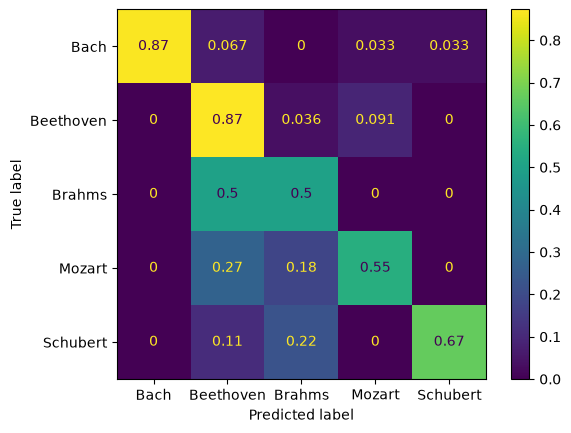

In [33]:
from matplotlib import pyplot as plt

metrics.ConfusionMatrixDisplay.from_predictions(
    all_work_true,
    all_work_pred,
    normalize="true"
)

plt.show()

---

## XGBoost

Gradient boosting ansambl — stabla se dodaju sekvencijalno, svako ispravlja greške prethodnih. Često
nadmaši Random Forest na ovakvim tabelarnim feature setovima. `LabelEncoder` je potreban jer XGBoost
očekuje numeričke labele, ne stringove.

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_midi)

all_work_true = []
all_work_pred = []

for train_idx, val_idx in sgkf.split(X_midi, y_midi, groups_midi):
    X_train_fold = X_midi[train_idx]
    y_train_fold = le.transform(y_midi[train_idx])
    groups_train = groups_midi[train_idx]

    X_val_fold = X_midi[val_idx]
    y_val_fold = y_midi[val_idx]
    groups_val = groups_midi[val_idx]

    sample_weights = make_sample_weights(y_midi[train_idx], groups_train)

    model = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_fold, y_train_fold, sample_weight=sample_weights)

    pred = le.inverse_transform(model.predict(X_val_fold))

    work_true, work_pred = majority_vote_prediction(y_val_fold, pred, groups_val)

    all_work_true.extend(work_true)
    all_work_pred.extend(work_pred)

print(metrics.classification_report(all_work_true, all_work_pred))